In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('../data/Louisville_Metro_KY_-_Library_Collection_Inventory_.csv')

In [8]:
df.head()

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice,ReportDate,ObjectId
0,707409,"Jeff Immelt and the new GE way : innovation, t...","Magee, David, 1965-",9.780072e+12,2009,Book,Adult Non-Fiction,Main,25.95,2022/07/01 04:00:00+00,1
1,1341361,McGraw-Hill's American idioms dictionary,"Spears, Richard A.",9.780071e+12,2007,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,2
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,3
3,1341362,McGraw-Hill's essential ESL grammar : a handbo...,"Lester, Mark.",9.780071e+12,2008,Book,ELL Collection,South Central,20.00,2022/07/01 04:00:00+00,4
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9.780307e+12,2009,Book,Adult Non-Fiction,Southwest,19.99,2022/07/01 04:00:00+00,5


## Cleaning the Data  
The dataset contains several issues that must be addressed before analysis:  
- The ISBN column dtype will be changed to 'string' as it is unchangeable and not useful for mathematical equations. 
- The 'ObjectId' and 'ReportDate' (if it is one date throughout the column) columns need to be dropped as they are not necessary to answer questions I have about the data.

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   BibNum           1657555 non-null  int64  
 1   Title            1657554 non-null  object 
 2   Author           1461831 non-null  object 
 3   ISBN             1422972 non-null  float64
 4   PublicationYear  1657555 non-null  int64  
 5   ItemType         1657555 non-null  object 
 6   ItemCollection   1657350 non-null  object 
 7   ItemLocation     1657555 non-null  object 
 8   ItemPrice        1657555 non-null  float64
 9   ReportDate       1657555 non-null  object 
 10  ObjectId         1657555 non-null  int64  
dtypes: float64(2), int64(3), object(6)
memory usage: 139.1+ MB


In [10]:
df = df.astype({'ISBN':'object'})
df.dtypes

BibNum               int64
Title               object
Author              object
ISBN                object
PublicationYear      int64
ItemType            object
ItemCollection      object
ItemLocation        object
ItemPrice          float64
ReportDate          object
ObjectId             int64
dtype: object

In [11]:
df['ISBN'] = df['ISBN'].astype(str)

In [12]:
df['ISBN'][0]

'9780071605878.0'

In [13]:
type(df['ISBN'][0])

str

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1657555 entries, 0 to 1657554
Data columns (total 11 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   BibNum           1657555 non-null  int64  
 1   Title            1657554 non-null  object 
 2   Author           1461831 non-null  object 
 3   ISBN             1657555 non-null  object 
 4   PublicationYear  1657555 non-null  int64  
 5   ItemType         1657555 non-null  object 
 6   ItemCollection   1657350 non-null  object 
 7   ItemLocation     1657555 non-null  object 
 8   ItemPrice        1657555 non-null  float64
 9   ReportDate       1657555 non-null  object 
 10  ObjectId         1657555 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 139.1+ MB


In [15]:
df.columns

Index(['BibNum', 'Title', 'Author', 'ISBN', 'PublicationYear', 'ItemType',
       'ItemCollection', 'ItemLocation', 'ItemPrice', 'ReportDate',
       'ObjectId'],
      dtype='object')

In [16]:
df.drop(['ObjectId'], axis=1, inplace =True)


In [17]:
df['ReportDate'].unique()

array(['2022/07/01 04:00:00+00'], dtype=object)

In [18]:
df.drop(['ReportDate'], axis=1, inplace=True)

In [19]:
df.columns

Index(['BibNum', 'Title', 'Author', 'ISBN', 'PublicationYear', 'ItemType',
       'ItemCollection', 'ItemLocation', 'ItemPrice'],
      dtype='object')

## EDA
Missing data will be handled as shown below:
- The row with 'Title' == NaN will be dropped as it contains very little data.
- For rows with 'Author' == NaN, many item types and books do not have an author. The data will be left as is if it does not show anything abnormal.
- Due to a very low percentage of 'ItemCollection' == NaN and the wide variety of options regarding 'ItemCollection', it will be left as is.
- For instances where 'PublicationYear' or 'ItemPrice' is equal to 0, it will be left as is since there is no way to verify from the data if the data is missing or 0 as not all items in the library collection have a publication year or an item price (donations).

Any visualizations using columns with missing data will be noted in the visualization markdown.

Regarding duplicated rows, rows cannot be validated as duplicated data or as simply duplicate items in the library inventory.

In [20]:
df.isna()

df.isna().sum()

BibNum                  0
Title                   1
Author             195724
ISBN                    0
PublicationYear         0
ItemType                0
ItemCollection        205
ItemLocation            0
ItemPrice               0
dtype: int64

In [21]:
df.loc[df['Title'].isna()]

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
243965,2239375,NaN,NaN,nan,0,Book,NaN,Crescent Hill,0.0


In [22]:
df = df.drop(243965)

In [23]:
df.isna().sum()

BibNum                  0
Title                   0
Author             195723
ISBN                    0
PublicationYear         0
ItemType                0
ItemCollection        204
ItemLocation            0
ItemPrice               0
dtype: int64

In [24]:
Author_na = df['Author'].isna()
Author_na

0          False
1          False
2          False
3          False
4          False
           ...  
1657550    False
1657551    False
1657552    False
1657553    False
1657554    False
Name: Author, Length: 1657554, dtype: bool

In [25]:
df.groupby(Author_na)['ItemType'].value_counts().unstack(fill_value=0)


ItemType,Archival/Mixed Materials,Atlas,Audio Book on CD,Audio Books,Blu-ray + DVD,Blu-ray Disc,Book,Book + CD,Book + DVD,Braille,...,Projected Medium,Recorded Events,Serial,Sound Recording,Streaming Music,Streaming Video,Three Dimensional Object (Artifact),Two Dimensional Nonprojected Graphic,Videorecording,Videotape
Author,,,,,,,,,,,,,,,,,,,,,
False,3,170,45047,7697,0,0,1115697,28,11,62,...,0,283,6583,991,4636,9810,0,15,31,0
True,2,54,1062,142,36,4439,65643,9,175,3,...,109,1,33306,6,802,7603,302,20,959,4


In [26]:
df[df['ItemType'] == 'Book'].value_counts()

BibNum   Title                                                            Author                                                  ISBN             PublicationYear  ItemType  ItemCollection          ItemLocation               ItemPrice
399459   Lineage book                                                     Daughters of the American Revolution.                   nan              1896             Book      Kentucky History        Main                       75.00        166
1402638  Inglés para latinos. un camino hacia la fluidez-- Primer nivel  Harvey, William C.                                      9781438070599.0  2011             Book      ELL Collection          Iroquois                   24.99         65
427457   Guide to civilian organizations ...                              United States. Work Projects Administration. Kentucky.  nan              1942             Book      Kentucky History        Main                       75.00         63
437021   Luther's works                

In [27]:
per_no_author_books = (65643 / 946859) * 100
per_no_author_books

6.93271120620916

In [28]:
df.loc[df['ItemCollection'].isna()]

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
8026,1353780,LANKIE MANTITA,LESLIE PATRICELLI,nan,0,Book,NaN,Shively,0.0
8587,2511351,My First Pet,NaN,nan,0,Book,NaN,Newburg,0.0
10501,1362079,Act of War,"Brown, Dale",nan,0,Book,NaN,Bon Air,0.0
16848,2410700,FOUR,VERONICA ROTH,nan,0,Book,NaN,Crescent Hill,0.0
22165,2481658,designing your work life,bill burnett,nan,0,Book,NaN,St Matthews,0.0
...,...,...,...,...,...,...,...,...,...
1656927,2528221,The Khipu and the Final Key,Dee Garretson,nan,0,Book,NaN,Northeast,0.0
1656933,2528222,MOMMY'S DISEASE,CAROLYN HANNAN,nan,0,Book,NaN,Southwest,0.0
1657038,2527377,use,NaN,nan,0,Book,NaN,Northeast,0.0
1657505,2527399,the girl in the road,MONICA BYRNE,nan,0,Book,NaN,Main,0.0


In [29]:
df.ItemCollection.unique()

array(['Adult Non-Fiction', 'ELL Collection', 'Adult Fiction', 'Mystery',
       'Adult Audiobook', 'Adult DVD', 'Electronic', 'Music',
       "Children's Picture Book", 'Science Fiction',
       'Book Discussion Kit', 'Older Teen Fiction',
       'Younger Teen  Fiction', 'Adult Paperback', "Children's Fiction",
       'Western', "Children's Picture Paperback", "Children's Paperback",
       'International Collection', 'Teen Non-Fiction',
       "Children's Non-Fiction", 'Kentucky History', 'Natural Resources',
       'Oversize', 'Holiday', 'Urban Fiction', 'Bestsellers',
       "Children's Board Book", 'Storytime Collection',
       'Preschool  Picture Book', "Children's Easy Reader", 'Readalongs',
       "Children's DVD", "Children's Reference", 'Adult Reference',
       'Interlibrary Loan', "Children's Music", nan,
       'Adult Paperbacks Tall', "Children's Easy Reader Paperback",
       'Large Print', 'Caldecott/Newbery', "Children's Audiobook",
       'OlderTeen Audiobook', 'Youn

In [30]:
item_collection_na = df.ItemCollection.isna().sum()
total_rows = df.shape[0]
per_item_collection_na = (item_collection_na / total_rows) * 100
per_item_collection_na

np.float64(0.01230729134616429)

In [31]:
zero_pub_yr = df[df['PublicationYear'] == 0]
zero_pub_yr

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
5054,1348353,Stolen legacy: the Egyptian origins of western...,"James, George G. M",nan,0,Book,Interlibrary Loan,Main,0.00
6417,1351064,Bước vào đời : tuồng cải lương,NaN,nan,0,DVD,Adult DVD,Iroquois,29.99
6515,1351072,Đừng phụ tình đời : DVD cải lương,NaN,nan,0,Videorecording,Adult DVD,Iroquois,29.99
6592,1351079,Người đẹp và tỷ phú,NaN,nan,0,DVD,Adult DVD,South Central,29.99
6721,1351089,Đẹp từng centimet.,NaN,nan,0,DVD,Adult DVD,South Central,29.99
...,...,...,...,...,...,...,...,...,...
1657143,2528085,"Cognitive Mapping : Past, Present, and Future","Kitchin, Rob",nan,0,Book,Interlibrary Loan,Main,0.00
1657146,2528087,Eye of the Beholder,"Krentz, Jayne",nan,0,Book,Interlibrary Loan,Main,0.00
1657175,2528088,Sharp Edges,"Krentz, Jayne",nan,0,Book,Interlibrary Loan,Main,0.00
1657505,2527399,the girl in the road,MONICA BYRNE,nan,0,Book,NaN,Main,0.00


In [32]:
zero_item_price = df[df['ItemPrice'] == 0]
zero_item_price

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
99,2263735,The Cornwalls Vanish,"DuBois, Brendan",9780316489256.0,2019,Ebook,Electronic,Main,0.0
350,2263736,The Best Cook in the World,"Bragg, Rick",9780525520283.0,2018,Ebook,Electronic,Main,0.0
351,2263737,The Art of Tapestry Weaving,"Mezoff, Rebecca",9781635861365.0,2020,Ebook,Electronic,Main,0.0
352,2263738,Cornwall's Wonderland,"Quiller-couch, Mabel",nan,2021,Ebook,Electronic,Main,0.0
353,2263739,Target: Alex Cross,"Patterson, James",9780316417518.0,2018,Ebook,Electronic,Main,0.0
...,...,...,...,...,...,...,...,...,...
1657502,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,0.0
1657503,2527398,Secret City,"Kirchick, James",9781250823793.0,2022,Eaudiobook,Electronic,Main,0.0
1657504,2527398,Secret City,"Kirchick, James",9781250823793.0,2022,Eaudiobook,Electronic,Main,0.0
1657505,2527399,the girl in the road,MONICA BYRNE,nan,0,Book,NaN,Main,0.0


In [33]:
df['ItemPrice'] = df['ItemPrice'].apply(lambda x: f'${x:,.2f}')

In [34]:
df[df['ItemPrice'] == 0.0]

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice


In [35]:
duplicated_mask = df.duplicated(keep=False)
duplicated_rows = df[duplicated_mask]
duplicated_rows

,BibNum,Title,Author,ISBN,PublicationYear,ItemType,ItemCollection,ItemLocation,ItemPrice
2,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,$19.99
4,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Southwest,$19.99
5,707411,Robin rescues dinner : 52 weeks of quick-fix m...,"Miller, Robin, 1964-",9780307451408.0,2009,Book,Adult Non-Fiction,Remote Shelving - Main,$19.99
6,1341364,Perfect phrases for ESL : everyday business life,"Gast, Natalie.",9780071608381.0,2010,Book,ELL Collection,Iroquois,$13.00
7,1341364,Perfect phrases for ESL : everyday business life,"Gast, Natalie.",9780071608381.0,2010,Book,ELL Collection,Iroquois,$13.00
...,...,...,...,...,...,...,...,...,...
1657500,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,$0.00
1657501,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,$0.00
1657502,2527397,A Duke for Diana,"Jeffries, Sabrina",9781420153781.0,2022,Ebook,Electronic,Main,$0.00
1657503,2527398,Secret City,"Kirchick, James",9781250823793.0,2022,Eaudiobook,Electronic,Main,$0.00


## EDA Plots (Item Totals)
Total Items by Library Branch:
- Some 'ItemLocation's need to be combined to get a total (i.e. 'Remote Shelving-Shawnee' to 'Shawnee').
- The 'ItemLocation' called 'Content Management' will be replaced with the standard location, 'Main,' as it only applies to 3 items and its meaning in unknown.
- A plot without the Main branch has been included as it has a disproportionate amount of items compared to the other branches. I would like to see a clearer comparison of those branches.
- A scattered bar chart is not very helpful due to the large amount of item types, but it does help confirm that majority of the item types are mostly located at the Main branch.   
- A bar chart showing only book items displays an exact trend as seen in the bar chart of all item types in which the Main branch has the vast majority of items and the branches go in the same order with book count.

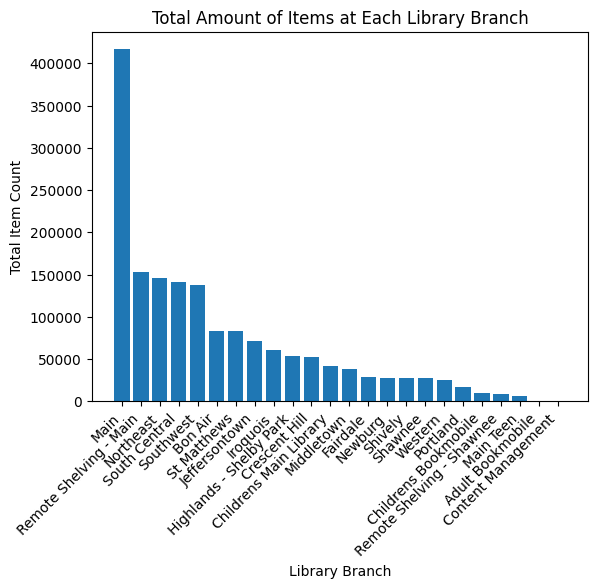

In [36]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

plt.show()

In [37]:
df['ItemLocation'] = df['ItemLocation'].replace('Remote Shelving - Shawnee', 'Shawnee')
df['ItemLocation'] = df['ItemLocation'].replace('Childrens Bookmobile', 'Bookmobile')
df['ItemLocation'] = df['ItemLocation'].replace('Adult Bookmobile', 'Bookmobile')
df['ItemLocation'] = df['ItemLocation'].replace(['Remote Shelving - Main', 'Childrens Main Library', 'Main Teen'], 'Main')

In [38]:
df[df['ItemLocation'] == 'Content Management'].value_counts()

BibNum  Title                                                                             Author                ISBN             PublicationYear  ItemType  ItemCollection   ItemLocation        ItemPrice
569591  The Penguin guide to compact discs and DVDs : Yearbook                            March, Ivan.          9780141027234.0  2006             Book      Adult Reference  Content Management  $22.00       1
807930  Effective phrases for performance appraisals : a guide to successful evaluations  Neal, James E. Jr.    9781882423125.0  2009             Book      Adult Reference  Content Management  $12.95       1
811188  Introducing RDA : a guide to the basics                                           Oliver, Chris, 1951-  9780838935941.0  2010             Book      Adult Reference  Content Management  $45.00       1
Name: count, dtype: int64

In [39]:
df['ItemLocation'] = df['ItemLocation'].replace('Content Management', 'Main')

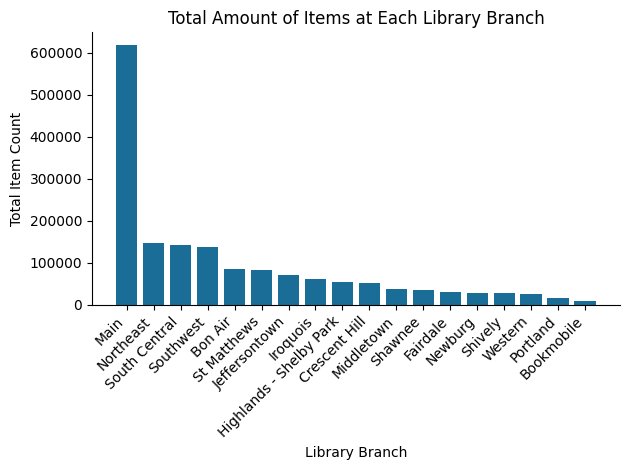

In [40]:
total_item_count = df['ItemLocation'].value_counts()
total_item_count

plt.bar(total_item_count.index, total_item_count.values, color="#1A6D96")
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each Library Branch')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/TotalItemAtEachBranchBar.png')
plt.show()

In [41]:
items_per_branch = df.groupby('ItemLocation')['ItemType'].value_counts().reset_index().sort_values(by='count', ascending=True)
items_per_branch

,ItemLocation,ItemType,count
367,Western,Two Dimensional Nonprojected Graphic,1
185,Middletown,Manuscript Material,1
186,Middletown,Printed Cartographic Material,1
187,Middletown,Three Dimensional Object (Artifact),1
188,Middletown,Two Dimensional Nonprojected Graphic,1
...,...,...,...
282,South Central,Book,114719
303,Southwest,Book,118845
207,Northeast,Book,122316
135,Main,Ebook,151681


In [42]:
pivot_df = items_per_branch.pivot(
    index='ItemLocation',
    columns='ItemType',
    values='count'
).fillna(0)

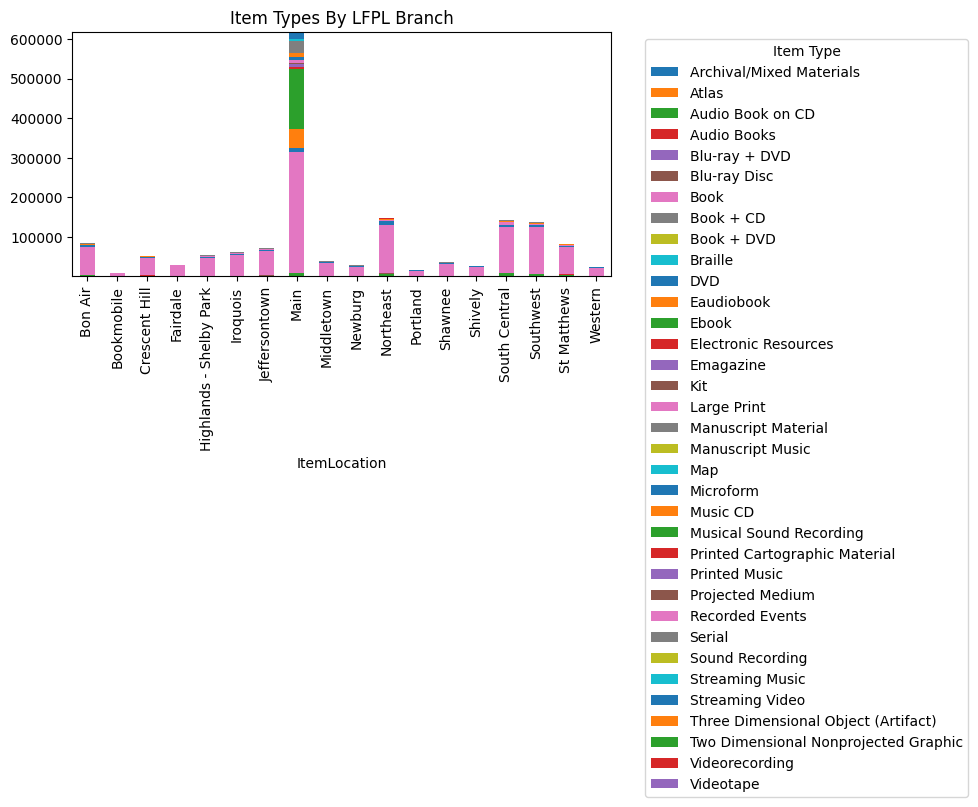

In [43]:
ax = pivot_df.plot(kind='bar', stacked=True, figsize=(10,6))

ax.set_title('Item Types By LFPL Branch')

ax.legend(
    title='Item Type',
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.tight_layout()
plt.show()

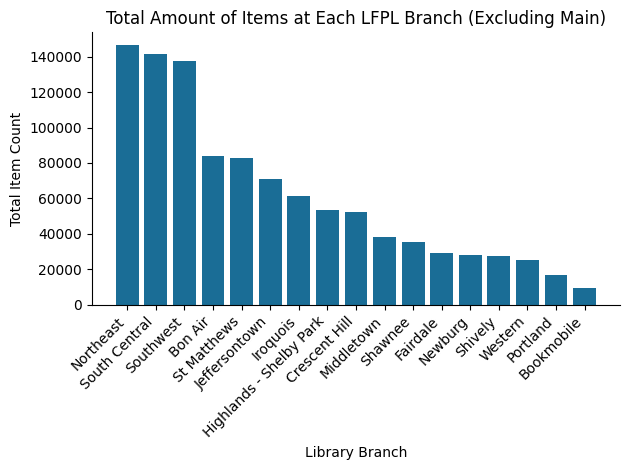

In [44]:
item_count_non_Main = (
    df[df['ItemLocation'] != 'Main']['ItemLocation']
    .value_counts())


plt.bar(item_count_non_Main.index, item_count_non_Main.values, color="#1A6D96")
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Item Count')
plt.title('Total Amount of Items at Each LFPL Branch (Excluding Main)')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/TotalItemAtEachBranchExceptMainBar.png')
plt.show()

In [45]:
df.ItemType.unique()

array(['Book', 'Audio Book on CD', 'DVD', 'Ebook', 'Music CD', 'Kit',
       'Eaudiobook', 'Atlas', 'Emagazine', 'Book + DVD', 'Videorecording',
       'Musical Sound Recording', 'Manuscript Material', 'Large Print',
       'Audio Books', 'Printed Music', 'Book + CD', 'Streaming Video',
       'Sound Recording', 'Braille', 'Serial',
       'Three Dimensional Object (Artifact)', 'Microform',
       'Electronic Resources', 'Blu-ray Disc', 'Recorded Events',
       'Streaming Music', 'Two Dimensional Nonprojected Graphic', 'Map',
       'Printed Cartographic Material', 'Videotape',
       'Archival/Mixed Materials', 'Projected Medium', 'Manuscript Music',
       'Blu-ray + DVD'], dtype=object)

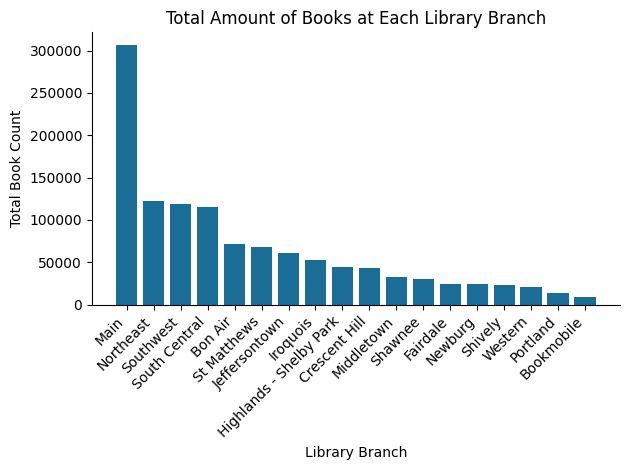

In [46]:
book_itemtype = df[df['ItemType'] == 'Book']
book_count = book_itemtype.groupby('ItemLocation')['ItemType'].size().sort_values(ascending=False)
book_count

plt.bar(book_count.index, book_count.values, color="#1A6D96")
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total Book Count')
plt.title('Total Amount of Books at Each Library Branch')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../plots/TotalBooksAtEachBranchBar.png')
plt.show()

## EDA Plots (Geographic Coverage)
Are there areas in Louisville that are underserved in regard to the library?
- A Pin Map is a helpful visual when looking at how the library branches impact the geography of the Louisville area. 
- The Main branch has the largest collection items, which makes sense as it is the oldest branch and also holds ownership over many of the electronic items.
- The Bookmobile location was not included as it does not have a set geographic location.

In [47]:
book_itemtype = df[df['ItemType'] == 'Book']
book_count = book_itemtype.groupby('ItemLocation')['ItemType'].size().sort_values(ascending=False)
book_count

ItemLocation
Main                       306286
Northeast                  122316
Southwest                  118845
South Central              114719
Bon Air                     72029
St Matthews                 68280
Jeffersontown               61113
Iroquois                    52738
Highlands - Shelby Park     44265
Crescent Hill               43156
Middletown                  32281
Shawnee                     30570
Fairdale                    24385
Newburg                     23742
Shively                     22799
Western                     20858
Portland                    13621
Bookmobile                   9337
Name: ItemType, dtype: int64

In [48]:
libraries = pd.DataFrame({
    "library_name": [
        "Main", "Northeast", "South Central", "Southwest", "Bon Air", "St. Matthews", "Jeffersontown", "Iroquois", "Highlands", "Crescent Hill", "Middletown", "Shawnee", "Fairdale", "Newburg", "Shively", "Western", "Portland"
    ],
    "books": [
        306286, 122316, 118845, 114719, 72029, 68280, 61113,
        52738, 44265, 43156, 32281, 30570, 24385, 23742, 22799, 20858, 13621
    ],
    "latitude": [  
        38.2449,  # Main
        38.2684,  # Northeast
        38.1447,  # South Central
        38.1700,  # Southwest
        38.2152,  # Bon Air
        38.2470,  # St Matthews
        38.1860,  # Jeffersontown
        38.1827,  # Iroquois
        38.2348,  # Highlands - Shelby Park
        38.2545,  # Crescent Hill
        38.2189,  # Middletown
        38.2529,  # Shawnee
        38.1079,  # Fairdale
        38.2219,  # Newburg
        38.2005,  # Shively
        38.2516,  # Western
        38.2692   # Portland
    ],
    "longitude": [
        -85.7577,  # Main
        -85.5763,  # Northeast
        -85.6756,  # South Central
        -85.7935,  # Southwest
        -85.6552,  # Bon Air
        -85.6586,  # St Matthews
        -85.5610,  # Jeffersontown
        -85.7715,  # Iroquois
        -85.7182,  # Highlands - Shelby Park
        -85.6911,  # Crescent Hill
        -85.5254,  # Middletown
        -85.8107,  # Shawnee
        -85.7610,  # Fairdale
        -85.7561,  # Newburg
        -85.8240,  # Shively
        -85.7764,  # Western
        -85.8110   # Portland
    ]
})


In [49]:
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.patheffects as pe

geometry = [Point(xy) for xy in zip(libraries["longitude"], libraries["latitude"])]

gdf_libraries = gpd.GeoDataFrame(libraries, geometry=geometry, crs="EPSG:4326")


In [50]:
zipcodes = gpd.read_file("../data/tl_2020_us_zcta520/tl_2020_us_zcta520.shp")


In [51]:
louisville_zips = zipcodes[zipcodes["ZCTA5CE20"].isin([
    "40202","40203","40204","40205","40206","40207","40208","40209",
    "40210","40211","40212","40213","40214","40215","40216","40217",
    "40218","40219","40220","40222","40223","40228","40229","40241",
    "40242","40243","40245","40258","40272","40291","40299", "40118"
])]


In [52]:
louisville_zips = louisville_zips.to_crs(gdf_libraries.crs)


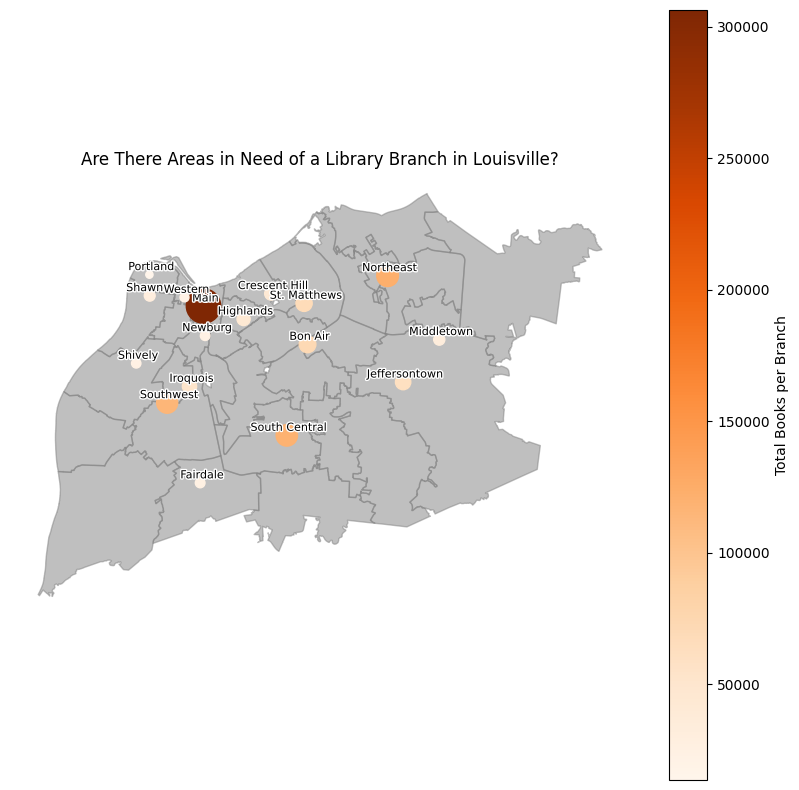

In [53]:
ax = louisville_zips.plot(
    figsize=(10, 10),
    color="grey",
    edgecolor="grey",
    alpha=0.5
)

ax = gdf_libraries.plot(
    ax=ax,
    column="books",
    cmap="Oranges",
    legend=True,
    markersize=gdf_libraries["books"] / 500,
    legend_kwds={
        "label": "Total Books per Branch",
        "orientation": "vertical"
    }
)

ax.set_title("Are There Areas in Need of a Library Branch in Louisville?", fontsize=12)
ax.axis("off")

for x, y, name in zip(
    gdf_libraries.geometry.x,
    gdf_libraries.geometry.y,
    gdf_libraries["library_name"]
):
   
    ax.text(
        x + 0.002,  # horizontal offset
        y + 0.002,  # vertical offset
        name,
        fontsize=8,
        color="black",
        ha="center",
        va="bottom",
        path_effects=[
        pe.withStroke (linewidth=2, foreground='white')   
        ]
    )
    plt.savefig('../plots/TotalBooksPinMap.png')
    


## EDA (Comparisons within the Collection)
- A simple pie chart shows a comparison of LFPL Ebook versus Physical Book holdings.

In [54]:
df.ItemType.unique()

array(['Book', 'Audio Book on CD', 'DVD', 'Ebook', 'Music CD', 'Kit',
       'Eaudiobook', 'Atlas', 'Emagazine', 'Book + DVD', 'Videorecording',
       'Musical Sound Recording', 'Manuscript Material', 'Large Print',
       'Audio Books', 'Printed Music', 'Book + CD', 'Streaming Video',
       'Sound Recording', 'Braille', 'Serial',
       'Three Dimensional Object (Artifact)', 'Microform',
       'Electronic Resources', 'Blu-ray Disc', 'Recorded Events',
       'Streaming Music', 'Two Dimensional Nonprojected Graphic', 'Map',
       'Printed Cartographic Material', 'Videotape',
       'Archival/Mixed Materials', 'Projected Medium', 'Manuscript Music',
       'Blu-ray + DVD'], dtype=object)

In [55]:
ebooks = df[df['ItemType'].isin(['Ebook'])]

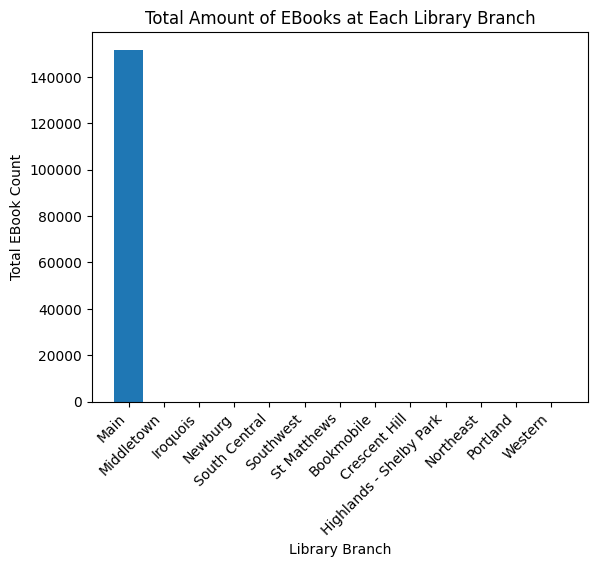

In [56]:
ebook_count = ebooks.groupby('ItemLocation')['ItemType'].size().sort_values(ascending=False)
ebook_count

plt.bar(ebook_count.index, ebook_count.values)
plt.xticks(rotation=45, ha='right')

plt.xlabel('Library Branch')
plt.ylabel('Total EBook Count')
plt.title('Total Amount of EBooks at Each Library Branch')

plt.show()

In [57]:
ebook_len = len(ebooks.value_counts())

In [58]:
book_len = len(df[df['ItemType'] == 'Book'].value_counts())

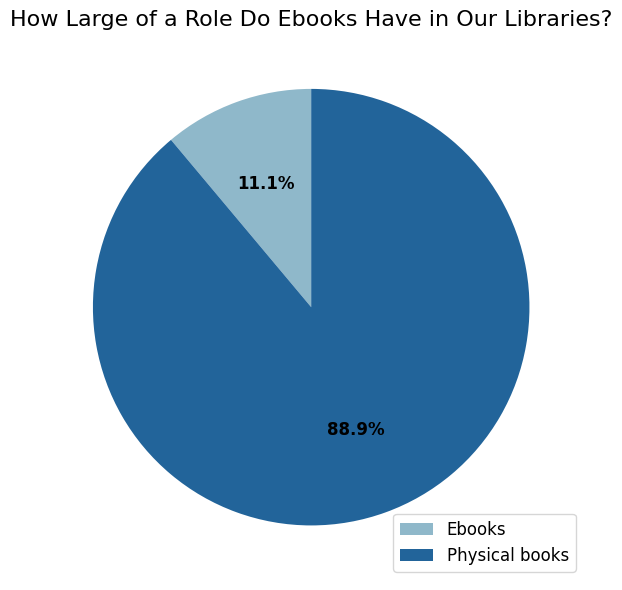

In [59]:
plt.figure(figsize=(6,6))
plt.pie(
    [ebook_len, book_len],
    labels=None,
    startangle=90,
    colors=["#8fb8caff", "#22649aff"],
    autopct='%1.1f%%',
    textprops={'fontsize' : 12, 'weight': 'bold'})

plt.title('How Large of a Role Do Ebooks Have in Our Libraries?', fontsize=16)
plt.legend(
    labels = ['Ebooks', 'Physical books'], fontsize=12,
    loc='lower right'
)


plt.tight_layout()
plt.savefig('../plots/BooksvsEbooksPieChart.png')
plt.show()


In [60]:
df['ItemCollection'].unique()

array(['Adult Non-Fiction', 'ELL Collection', 'Adult Fiction', 'Mystery',
       'Adult Audiobook', 'Adult DVD', 'Electronic', 'Music',
       "Children's Picture Book", 'Science Fiction',
       'Book Discussion Kit', 'Older Teen Fiction',
       'Younger Teen  Fiction', 'Adult Paperback', "Children's Fiction",
       'Western', "Children's Picture Paperback", "Children's Paperback",
       'International Collection', 'Teen Non-Fiction',
       "Children's Non-Fiction", 'Kentucky History', 'Natural Resources',
       'Oversize', 'Holiday', 'Urban Fiction', 'Bestsellers',
       "Children's Board Book", 'Storytime Collection',
       'Preschool  Picture Book', "Children's Easy Reader", 'Readalongs',
       "Children's DVD", "Children's Reference", 'Adult Reference',
       'Interlibrary Loan', "Children's Music", nan,
       'Adult Paperbacks Tall', "Children's Easy Reader Paperback",
       'Large Print', 'Caldecott/Newbery', "Children's Audiobook",
       'OlderTeen Audiobook', 'Youn

In [61]:
childrens_words = ['Children', 'Preschool', 'Storytime']
pattern = '|'.join(childrens_words)
childrens_df = df[
    df['ItemCollection'].str.contains(pattern, case=False, na=False)
]


In [62]:
childrens_df_byloc = childrens_df.groupby(['ItemLocation', 'ItemCollection']).size().reset_index(name='count')
childrens_df_byloc


,ItemLocation,ItemCollection,count
0,Bon Air,Children's Audiobook,283
1,Bon Air,Children's Blu-ray,63
2,Bon Air,Children's Board Book,950
3,Bon Air,Children's DVD,660
4,Bon Air,Children's Easy Reader,1194
...,...,...,...
297,Western,Children's Picture Book,1238
298,Western,Children's Picture Paperback,182
299,Western,Children's Reference,37
300,Western,Preschool Picture Book,1450


In [63]:
heatmap_data = childrens_df_byloc.pivot(
    index='ItemLocation',
    columns='ItemCollection',
    values='count'
).fillna(0)

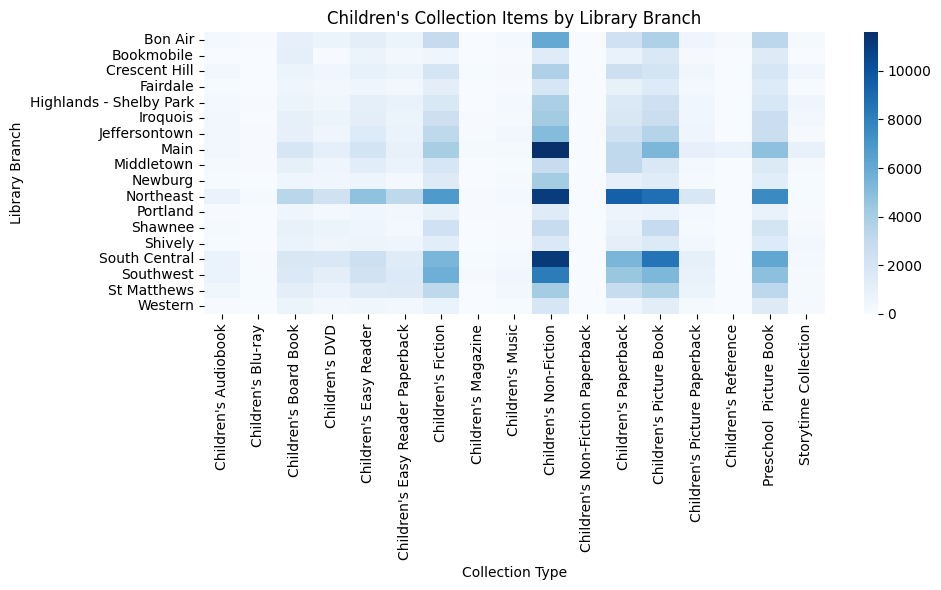

In [64]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Blues')

plt.title("Children's Collection Items by Library Branch")
plt.xlabel("Collection Type")
plt.ylabel("Library Branch")

plt.tight_layout()
plt.savefig('../plots/ChildrensCollectionHeatMap.png')
plt.show()

In [65]:
teen_words = ['Teen', 'College']
pattern = '|'.join(teen_words)
teens_df = df[
    df['ItemCollection'].str.contains(pattern, case=False, na=False)]

In [66]:
teens_df_byloc = teens_df.groupby(['ItemLocation', 'ItemCollection']).size().reset_index(name='count')
teens_df_byloc

,ItemLocation,ItemCollection,count
0,Bon Air,Older Teen Fiction,1170
1,Bon Air,Older Teen Paperback,2
2,Bon Air,OlderTeen Audiobook,63
3,Bon Air,Teen Non-Fiction,1318
4,Bon Air,Younger Teen Audiobook,85
...,...,...,...
133,Western,Teen Non-Fiction,777
134,Western,Teen Reference,1
135,Western,Younger Teen Audiobook,21
136,Western,Younger Teen Fiction,298


In [67]:
heatmap_data = teens_df_byloc.pivot(
    index='ItemLocation',
    columns='ItemCollection',
    values='count'
).fillna(0)

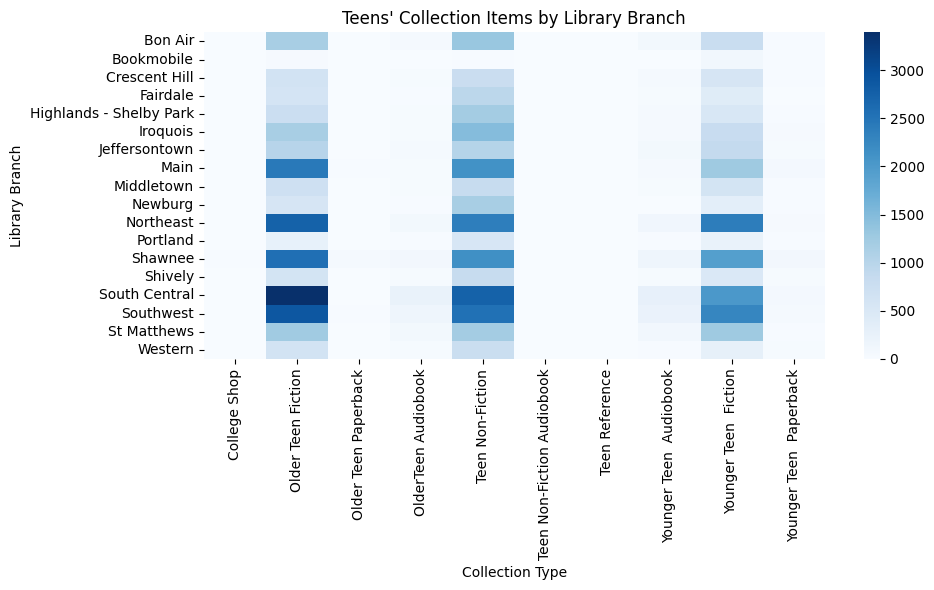

In [68]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Blues')

plt.title("Teens' Collection Items by Library Branch")
plt.xlabel("Collection Type")
plt.ylabel("Library Branch")

plt.tight_layout()
plt.savefig('../plots/TeensCollectionHeatMap.png')
plt.show()

In [69]:
adult_words = ['Adult', 'ELL', 'Mystery', 'Science', 'Western', 'International', 'Kentucky', 'Natural', 'Oversize','Holiday', 'Urban', 'Bestsellers', 'Large', 'Caldecott/Newberry', 'Government', 'Telereference', 'Big', 'Magazines']
pattern = '|'.join(adult_words)
adults_df = df[
    df['ItemCollection'].str.contains(pattern, case=False, na=False)]

In [70]:
adults_df_byloc = adults_df.groupby(['ItemLocation', 'ItemCollection']).size().reset_index(name='count')
adults_df_byloc

,ItemLocation,ItemCollection,count
0,Bon Air,Adult Audiobook,2496
1,Bon Air,Adult Blu-Ray,156
2,Bon Air,Adult DVD,2714
3,Bon Air,Adult Fiction,13533
4,Bon Air,Adult Non-Fiction,19982
...,...,...,...
338,Western,Mystery,324
339,Western,Oversize,23
340,Western,Science Fiction,68
341,Western,Urban Fiction,725


In [71]:
heatmap_data = adults_df_byloc.pivot(
    index='ItemLocation',
    columns='ItemCollection',
    values='count'
).fillna(0)

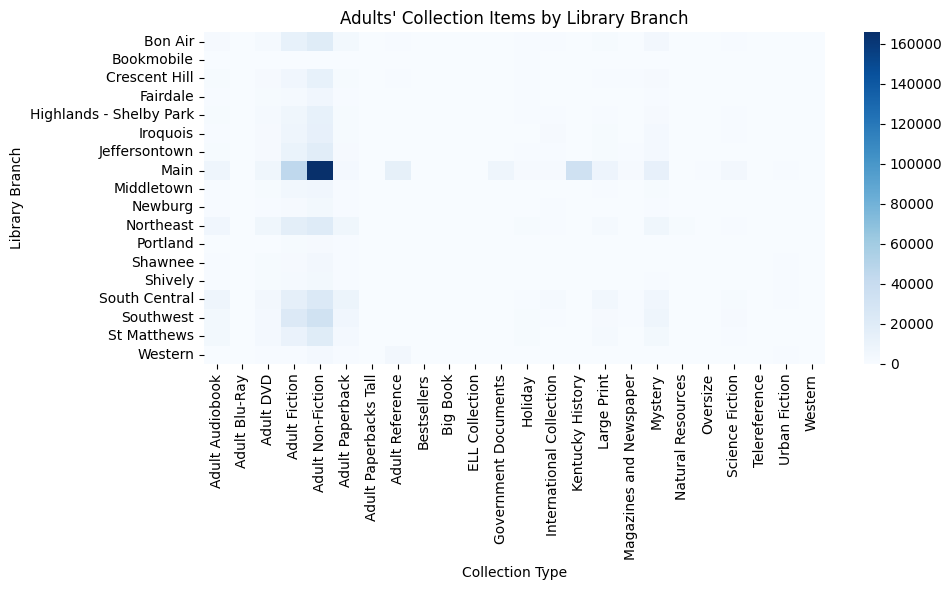

In [72]:
plt.figure(figsize=(10, 6))
sns.heatmap(heatmap_data, cmap='Blues')

plt.title("Adults' Collection Items by Library Branch")
plt.xlabel("Collection Type")
plt.ylabel("Library Branch")

plt.tight_layout()
plt.savefig('../plots/AdultsCollectionHeatMap.png')
plt.show()